## Laboratorio 4

- Diego Valenzuela 22309 
- Daniel Dubon 22233
- Nelson García Bravatti 22434
- Joaquin Puente 22296

### Task 1 Diseño

1. Espacio de Estados y Espacio de Acciones

    Espacio de Estados: El almacen es una cuadricula de 8 x 8.

    Eleccioó: gymnasium spaces Discrete 64

    Justificación: Un espacio Discreto 64 mapea cada celda bidimensional a un unico numero entero entre 0 y 63 y esto es ideal y necesario porque tanto SARSA como Q Learning, en sus formas clasicas tabulares, requieren un estado discreto para usarse como indice en la matriz o Q Table de dimensiones 64 x 4.

    Por que no usar Box: La clase Box se utiliza para representar espacios continuos como arreglos de numeros decimales. Si se usara Box el espacio de estados seria infinito y no se podria construir una Q Table clasica y nos veriamos obligados a usar aproximadores de funciones lo cual esta fuera del alcance de una comparacion estandar de SARSA contra Q Learning.

    Espacio de Acciones: Movimientos direccionales del robot.

    Elección: gymnasium spaces Discrete 4

    Justificación: Representa 4 acciones deterministas y mutuamente excluyentes: Arriba 0, Abajo 1, Izquierda 2, Derecha 3.


2. Función de Recompensa

    - Recompensa por entrega exitosa: +100
    - Penalización por zona de congestion: -20 y se aplica cada vez que se pisa o permanece en una celda de congestion.
    - Penalización por paso:  -1 y se aplica en cualquier otra celda transitable.


    Justificación de las magnitudes:

    El objetivo es que el robot llegue a la meta de la forma mas rapida por la penalizacion por paso y segura por la penalización por congestion y aumentar 100 garantiza que llegar a la meta sea el evento dominante y el objetivo global del episodio, El menos 1 fuerza al robot a buscar la ruta mas corta y el menos 20 es lo suficientemente grande como para disuadir al robot de cruzar la congestion tambien cabe resaltar que cruzar una celda de congestion cuesta lo mismo que dar 20 pasos normales.

    Comportamientos indeseables por mala ponderación:

    Si la penalización por congestion es menor o igual a la penalización por paso el robot desarrollara un comportamiento temerario y si rodear la congestion toma 3 pasos extra pero cruzarla cuesta menos puntos el agente preferira atravesar la congestion. Si la penalizacion por paso es cero o positiva el robot perdera el sentido de urgencia y caminara en circulos infinitamente sin incentivo para llegar a la meta. Si la penalización por congestion es excesivamente alta, por ejemplo menos 1000: Podria provocar que durante la exploracion temprana el agente asocie todo el entorno con un peligro extremo y aprenda una politica suboptima de quedarse quieto o chocar contra la pared constantemente para terminar el episodio rapidamente y evitar castigos.

3. Condición de Terminación del Episodio

    El episodio terminara por cualquiera de estas dos condiciones:

    - Terminated o Estado Terminal Natural: El robot alcanza el estado del Punto de Entrega.
    - Truncated o Limite Maximo de Pasos: El episodio alcanza un limite, por ejemplo un maximo de 100 pasos.

    Es apropiado tener un limite maximo de pasos:

    Si, es necesario porque durante las primeras fases de entrenamiento la politica del robot es casi completamente aleatoria y sin un limite de pasos el robot podria entrar en bucles infinitos en zonas sin penalizaciones, o simplemente vagar sin encontrar la meta jamas y el limite asegura que los episodios finalicen, garantizando que el agente experimente repetidas veces el reinicio del entorno y converja matematicamente.

4. Diseño del Mapa 8 por 8

    Para que la diferencia entre una politica agresiva y una politica conservadora sea empiricamente visible diseñamos el mapa inspirandonos en el problema clasico de Cliff Walking.

    Leyenda de las celdas:
    S: Punto de recogida
    G: Punto de entrega
    P: Pasillo transitable
    O: Obstaculo fijo
    C: Zona de congestion

    Esquema de las primeras 4 filas:

    --

    S P P P P P P G

    O C C C C C C P

    P P P P P P P P

    P O O P O O O P

    --

    Analisis de la configuración espacial:

    En este mapa la primera fila representa una ruta directa muy rapida entre el punto de recogida y la meta, sin embargo justo debajo hay una hilera de Zonas de Congestion y si un robot esta en la fila de arriba y toma una decision aleatoria hacia abajo caera en la congestion, existe una segunda ruta segura por debajo de los obstaculos pero toma muchos mas pasos.

    Comportamiento diferencial esperado:

    Con Q Learning Agresivo y Off Policy esperamos que aprenda la funcion de valor optima asumiendo que actuara siempre de forma ambiciosa, en este caso aprendera que la ruta optima es ir en linea recta por la fila de arriba, sin embargo durante el entrenamiento con mucha exploración, su constante curiosidad hara que resbale frecuentemente hacia abajo sufriendo muchas penalizaciones y su politica es optima en la teoria pero altamente riesgosa en la practica.

    Con SARSA conservador y On Policy: Aqui se actualizan sus valores basandose en la accion real que va a tomar incluyendo los movimientos aleatorios de exploracion donde SARSA aprende que caminar por la fila de arriba es peligroso porque hay probabilidad de terminar en la congestión, por lo tanto SARSA convergera hacia una ruta mas larga pero segura, bajando para alejarse de la zona de congestión, minimizando las penalizaciones durante el entrenamiento a costa de dar mas pasos.

### Preguntas previas a la implementación

**1. Predicción formal: recompensa acumulada en entrenamiento vs. evaluación greedy**

Las reglas de actualización son:

- SARSA (on-policy): $Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma Q(s',a') - Q(s,a)\right]$, donde $a'$ es la acción realmente elegida por la política $\varepsilon$-greedy en $s'$.
- Q-Learning (off-policy): $Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]$, sin importar qué acción se ejecute realmente.

En nuestro mapa, la fila 0 (ruta corta S→G) es adyacente a una fila completa de congestión (fila 1). Para cualquier estado de la fila 0, la acción "abajo" cae en congestión (-20).

- Durante **entrenamiento**, SARSA incorpora en su target el valor esperado bajo la política que realmente se ejecuta, es decir, con probabilidad $\varepsilon$ el agente puede tomar una acción aleatoria y caer en congestión. Esto hace que $Q(s,\text{arriba/derecha})$ de los estados de la fila 0 quede penalizado por ese riesgo, empujando a SARSA a preferir la ruta segura de la fila 2 (más pasos, pero sin exposición a -20). Resultado: **SARSA acumula mayor recompensa durante el entrenamiento** porque su política de comportamiento evita activamente la congestión mientras explora.
- Q-Learning usa $\max_{a'}Q(s',a')$ en el target, ignorando que la acción real puede ser exploratoria. Por lo tanto, aprende que la fila 0 es óptima (siempre y cuando actúe greedy), pero mientras entrena con $\varepsilon$-greedy sigue tomando pasos aleatorios que lo tiran a la congestión con frecuencia. Resultado: **Q-Learning tiene menor recompensa acumulada durante el entrenamiento** (más caídas en zona de congestión, análogo al problema clásico de "Cliff Walking").
- Durante **evaluación con política greedy pura** ($\varepsilon=0$), ya no hay exploración: el entorno es determinista, así que no hay riesgo de "resbalar". Q-Learning ejecuta la ruta óptima real (fila 0, distancia mínima = 7 pasos), obteniendo la recompensa más alta posible. SARSA, en cambio, quedó convergido a la ruta conservadora de la fila 2 (más larga), por lo que su recompensa en evaluación greedy es menor que la de Q-Learning aunque siga siendo positiva y estable.

En resumen: **SARSA gana en entrenamiento, Q-Learning gana en evaluación greedy**. Esto es exactamente el resultado esperado por la propiedad on-policy vs. off-policy combinada con la geometría tipo "cliff" del mapa.

**2. Efecto de $\varepsilon$ y condición de convergencia a políticas idénticas**

El target de SARSA puede escribirse como una esperanza sobre la política de comportamiento:

$$\mathbb{E}_{a'\sim\pi_\varepsilon}[Q(s',a')] = (1-\varepsilon)\max_{a'}Q(s',a') + \frac{\varepsilon}{|A|}\sum_{a'}Q(s',a')$$

mientras que el target de Q-Learning es directamente $\max_{a'}Q(s',a')$.

La diferencia entre ambos targets es:

$$\Delta = \max_{a'}Q(s',a') - \mathbb{E}_{a'\sim\pi_\varepsilon}[Q(s',a')] = \varepsilon\left(\max_{a'}Q(s',a') - \frac{1}{|A|}\sum_{a'}Q(s',a')\right)$$

Esta expresión es **lineal en $\varepsilon$** y su segundo factor es siempre $\geq 0$ (el máximo nunca es menor que el promedio). Por lo tanto:

- Cuanto mayor es $\varepsilon$, mayor es la brecha entre SARSA y Q-Learning, y más conservadora se vuelve la política de SARSA respecto a la fila de congestión.
- Cuando $\varepsilon \to 0$, $\Delta \to 0$: las dos reglas de actualización se vuelven **matemáticamente idénticas** ($\pi_\varepsilon \to$ greedy), por lo que ambos algoritmos convergen a la misma política óptima determinista $\pi^*$ (la ruta por la fila 0).

Sí existe entonces un valor de $\varepsilon$ para el cual ambos convergen a políticas idénticas: **$\varepsilon = 0$** (equivalente a que $\varepsilon$ decaiga a 0 durante el entrenamiento, cumpliendo condiciones GLIE). La salvedad es que con $\varepsilon=0$ fijo desde el inicio no hay exploración, por lo que la garantía de convergencia al óptimo requiere que $\varepsilon$ decaiga gradualmente (arrancando $>0$ para explorar y tendiendo a 0), no que sea 0 desde el primer episodio.

**3. Cota superior de $V^*(s_0)$**

Asumiendo que el agente sigue siempre la ruta más corta sin pisar congestión, la ruta óptima es la fila 0 completa: $S=(0,0) \to G=(0,7)$, con distancia Manhattan $d = 7$ pasos (sin obstáculos ni congestión en esa fila).

De esos 7 pasos, los primeros $d-1=6$ caen en celdas de pasillo (-1 cada uno) y el último paso entra a la meta (+100). Con factor de descuento $\gamma$, la cota superior es:

$$V^*(s_0) \;\leq\; \sum_{t=0}^{d-2} \gamma^{t}\,(-1) \;+\; \gamma^{\,d-1}\,(100) \;=\; -\left(\frac{1-\gamma^{6}}{1-\gamma}\right) + 100\,\gamma^{6}$$

Casos concretos:

- Sin descuento ($\gamma=1$): $V^*(s_0) \leq 6(-1) + 100 = 94$.
- Con $\gamma=0.99$: $V^*(s_0) \leq -5.853 + 100(0.941) \approx 88.3$.
- Con $\gamma=0.9$: $V^*(s_0) \leq -4.686 + 100(0.531) \approx 48.4$.

Esta cota (94 para el caso no descontado, que es el que usamos en la implementación tabular) sirve como referencia: cualquier retorno de evaluación greedy que obtengamos de SARSA o Q-Learning debe estar por debajo o igual a 94, y qué tan cerca esté cada algoritmo de ese valor mide su cercanía al óptimo teórico.


### Task 3

#### Corrección al mapa diseñado en Task 1

Al implementar el mapa tal como quedó escrito en Task 1 detectamos dos problemas que lo hacían
inservible para comparar SARSA contra Q-Learning, y los verificamos empíricamente entrenando ambos
algoritmos sobre las variantes:

1. **No existía la "segunda ruta segura".** Con la fila 1 definida como `O C C C C C C P`, la celda
   `(1,0)` era un obstáculo, así que desde `S=(0,0)` el único movimiento posible era avanzar por la
   fila 0. Toda bajada intermedia caía en congestión y la única celda transitable de la fila 1
   (`(1,7)`) está debajo de la meta, a la que solo se llega terminando el episodio. En la práctica el
   mapa tenía **una sola ruta**, y ambos algoritmos convergían necesariamente a la misma política.

2. **La ruta alternativa estaba igual de expuesta.** Aun corrigiendo `(1,0)`, la ruta "segura" por la
   fila 2 está pegada por debajo a la misma hilera de congestión, con exactamente la misma
   probabilidad de resbalar hacia ella que la fila 0. Al ser 4 pasos más larga sin reducir el riesgo,
   SARSA nunca tenía motivo para preferirla. Lo comprobamos con tres variantes de mapa, tres valores
   de penalización y tres valores de $\varepsilon$: en todos los casos ambos algoritmos aprendían la
   misma política greedy.

La causa de fondo es que en el mapa original la congestión quedaba **al costado** de la ruta corta,
mientras que en el problema de Cliff Walking en el que nos inspiramos el peligro está **entre** el
inicio y la meta. Reacomodamos el mapa para respetar esa geometría, manteniendo intactos el espacio
de estados (`Discrete(64)`), el de acciones (`Discrete(4)`) y la función de recompensa
(+100 meta, −20 congestión, −1 paso):

```
S ~ ~ ~ ~ ~ ~ G     fila 0: recogida, banda de congestion, entrega
. . . . . . . .     fila 1: ruta corta y arriesgada (9 pasos, pegada a la congestion)
. . . . . . . .     fila 2: ruta larga y segura (11 pasos, sin exposicion)
. # # . # # # .     fila 3: obstaculos fijos
. . . . . . . .
. # # # # # # .
. . . . . . . .
. . . . . . . .
```

Con este mapa el comportamiento diferencial que predijimos sí aparece: la ruta óptima real (fila 1)
bordea la congestión, y solo cuesta 2 pasos más rodearla por la fila 2.

**Consecuencia sobre la cota de Task 2:** la ruta óptima ya no mide 7 pasos sino 9, así que la cota
no descontada pasa de 94 a $8(-1) + 100 = 92$. Con $\gamma = 0.99$ la cota es
$-\left(\frac{1-0.99^{8}}{1-0.99}\right) + 100(0.99^{8}) \approx 84.6$. El resto del análisis de
Task 2 (on-policy vs off-policy, efecto de $\varepsilon$, convergencia idéntica en $\varepsilon=0$)
no cambia.

**Hiperparámetros usados:** $\alpha = 0.1$, $\gamma = 0.99$, $\varepsilon = 0.2$ fijo, 20000
episodios de entrenamiento, límite de 100 pasos por episodio y 100 episodios de evaluación greedy pura
($\varepsilon = 0$).

Dos de estos valores los elegimos a partir de un control de robustez sobre 10 semillas distintas, no
por conveniencia de una corrida puntual:

- **$\varepsilon = 0.2$.** Con $\varepsilon = 0.1$ el riesgo esperado de resbalar (≈0.15 caídas ×
  ≈21 puntos) no alcanza a compensar los 2 pasos extra del rodeo, y ambos algoritmos vuelven a
  converger a la misma política. Esto es consistente con el análisis de Task 2: la brecha entre los
  targets de SARSA y Q-Learning es lineal en $\varepsilon$, así que hace falta suficiente exploración
  para que la aversión al riesgo de SARSA se manifieste.
- **20000 episodios.** Con 8000 episodios SARSA elegía la ruta segura solo en 8 de 10 semillas
  (en las otras 2 todavía no había terminado de converger y coincidía con Q-Learning). Con 20000
  episodios el resultado es 10 de 10 semillas, y SARSA supera a Q-Learning en recompensa de
  entrenamiento en las 10. Q-Learning converge antes: aprende la ruta corta en 10 de 10 semillas ya
  con 8000 episodios. Esa diferencia de velocidad de convergencia es en sí misma un resultado del
  experimento.

#### 1. El entorno: `WarehouseEnv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import gymnasium as gym
from gymnasium import spaces

# Leyenda: S=recogida, G=entrega, P=pasillo, O=obstaculo fijo, C=zona de congestion
MAPA = [
    "SCCCCCCG",
    "PPPPPPPP",
    "PPPPPPPP",
    "POOPOOOP",
    "PPPPPPPP",
    "POOOOOOP",
    "PPPPPPPP",
    "PPPPPPPP",
]

R_META = 100.0
R_CONGESTION = -20.0
R_PASO = -1.0


class WarehouseEnv(gym.Env):
    """Almacen 8x8 para un robot de reparto.

    Observacion : Discrete(64), indice del estado = fila * 8 + columna.
    Accion      : Discrete(4)  -> 0 arriba, 1 abajo, 2 izquierda, 3 derecha.
    Recompensa  : +100 al entrar a la meta, -20 al pisar o permanecer en congestion,
                  -1 en cualquier otro caso.
    Terminacion : terminated cuando el robot entra a la meta.
                  truncated  cuando se agota el limite de pasos del episodio.
    """

    metadata = {"render_modes": ["human", "ansi", "matplotlib"], "render_fps": 4}

    ACCIONES = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    NOMBRES_ACCIONES = {0: "arriba", 1: "abajo", 2: "izquierda", 3: "derecha"}
    FLECHAS = {0: "^", 1: "v", 2: "<", 3: ">"}

    def __init__(self, mapa=MAPA, max_pasos=100, render_mode=None):
        super().__init__()
        self.mapa = [list(fila) for fila in mapa]
        self.n_filas = len(self.mapa)
        self.n_cols = len(self.mapa[0])
        self.max_pasos = max_pasos
        self.render_mode = render_mode

        self.observation_space = spaces.Discrete(self.n_filas * self.n_cols)
        self.action_space = spaces.Discrete(4)

        self.inicio = self._buscar("S")
        self.meta = self._buscar("G")

        self.pos = self.inicio
        self.pasos = 0

    # ---------------------------------------------------------------- utilidades
    def _buscar(self, simbolo):
        for f in range(self.n_filas):
            for c in range(self.n_cols):
                if self.mapa[f][c] == simbolo:
                    return (f, c)
        raise ValueError(f"El mapa no contiene el simbolo {simbolo}")

    def a_estado(self, pos):
        """Convierte una posicion (fila, columna) al indice discreto del estado."""
        return pos[0] * self.n_cols + pos[1]

    def a_posicion(self, estado):
        """Convierte un indice discreto de estado a la posicion (fila, columna)."""
        return divmod(estado, self.n_cols)

    def _transitable(self, pos):
        f, c = pos
        if not (0 <= f < self.n_filas and 0 <= c < self.n_cols):
            return False
        return self.mapa[f][c] != "O"

    # ---------------------------------------------------------------- API Gymnasium
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.pos = self.inicio
        self.pasos = 0
        info = {"pos": self.pos, "congestion": False, "pasos": 0}
        if self.render_mode == "human":
            self.render()
        return self.a_estado(self.pos), info

    def step(self, accion):
        assert self.action_space.contains(accion), f"Accion invalida: {accion}"
        df, dc = self.ACCIONES[int(accion)]
        candidata = (self.pos[0] + df, self.pos[1] + dc)

        # Chocar contra una pared o un obstaculo deja al robot donde estaba.
        if self._transitable(candidata):
            self.pos = candidata

        self.pasos += 1
        celda = self.mapa[self.pos[0]][self.pos[1]]

        terminated = celda == "G"
        if terminated:
            recompensa = R_META
        elif celda == "C":
            recompensa = R_CONGESTION      # se cobra al pisar y al permanecer
        else:
            recompensa = R_PASO

        truncated = (not terminated) and self.pasos >= self.max_pasos
        info = {"pos": self.pos, "congestion": celda == "C", "pasos": self.pasos}

        if self.render_mode == "human":
            self.render()
        return self.a_estado(self.pos), recompensa, terminated, truncated, info

    # ---------------------------------------------------------------- render
    def render(self):
        modo = self.render_mode or "ansi"
        if modo == "matplotlib":
            return self._render_matplotlib()
        texto = self._render_texto()
        if modo == "human":
            print(texto)
            return None
        return texto

    def _render_texto(self):
        simbolos = {"S": " S ", "G": " G ", "P": " . ", "O": " # ", "C": " ~ "}
        lineas = [f"paso {self.pasos}/{self.max_pasos}   pos={self.pos}"]
        for f in range(self.n_filas):
            fila = ""
            for c in range(self.n_cols):
                fila += "[A]" if (f, c) == self.pos else simbolos[self.mapa[f][c]]
            lineas.append(fila)
        lineas.append("A=agente  S=recogida  G=entrega  #=obstaculo  ~=congestion  .=pasillo")
        return "\n".join(lineas)

    def _grid_codificado(self):
        codigo = {"P": 0, "S": 1, "G": 2, "O": 3, "C": 4}
        return np.array([[codigo[c] for c in fila] for fila in self.mapa])

    def _render_matplotlib(self, ax=None):
        cmap = ListedColormap(["#f2f2f2", "#4c9be8", "#3fa34d", "#3b3b3b", "#e07b39"])
        creado = ax is None
        if creado:
            _, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(self._grid_codificado(), cmap=cmap, vmin=0, vmax=4)
        ax.scatter(self.pos[1], self.pos[0], s=380, c="red", zorder=3, label="agente")
        ax.set_xticks(np.arange(-0.5, self.n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.n_filas, 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.5)
        ax.set_xticks(range(self.n_cols))
        ax.set_yticks(range(self.n_filas))
        ax.set_title(f"WarehouseEnv - paso {self.pasos} - pos {self.pos}")
        ax.legend(loc="upper right")
        if creado:
            plt.show()
        return ax

#### 2. Verificación del entorno

In [2]:
env = WarehouseEnv()

print("observation_space:", env.observation_space)
print("action_space     :", env.action_space)
print("inicio S:", env.inicio, "-> estado", env.a_estado(env.inicio))
print("meta   G:", env.meta, "-> estado", env.a_estado(env.meta))

estado, info = env.reset(seed=0)
print("\nreset() ->", estado, info)
print(env.render())

observation_space: Discrete(64)
action_space     : Discrete(4)
inicio S: (0, 0) -> estado 0
meta   G: (0, 7) -> estado 7

reset() -> 0 {'pos': (0, 0), 'congestion': False, 'pasos': 0}
paso 0/100   pos=(0, 0)
[A] ~  ~  ~  ~  ~  ~  G 
 .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
 .  #  #  .  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  #  #  #  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
A=agente  S=recogida  G=entrega  #=obstaculo  ~=congestion  .=pasillo


In [3]:
# Un episodio corto con acciones fijas para comprobar step(), las recompensas y la terminacion.
env_demo = WarehouseEnv(render_mode="human")
env_demo.reset(seed=0)

for accion in [1, 3, 3, 0]:   # abajo, derecha, derecha, arriba (arriba entra a congestion)
    estado, r, terminated, truncated, info = env_demo.step(accion)
    print(f"accion={env_demo.NOMBRES_ACCIONES[accion]:<10} estado={estado:<3} r={r:>6} "
          f"congestion={info['congestion']} terminated={terminated} truncated={truncated}")

paso 0/100   pos=(0, 0)
[A] ~  ~  ~  ~  ~  ~  G 
 .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
 .  #  #  .  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  #  #  #  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
A=agente  S=recogida  G=entrega  #=obstaculo  ~=congestion  .=pasillo
paso 1/100   pos=(1, 0)
 S  ~  ~  ~  ~  ~  ~  G 
[A] .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
 .  #  #  .  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  #  #  #  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
A=agente  S=recogida  G=entrega  #=obstaculo  ~=congestion  .=pasillo
accion=abajo      estado=8   r=  -1.0 congestion=False terminated=False truncated=False
paso 2/100   pos=(1, 1)
 S  ~  ~  ~  ~  ~  ~  G 
 . [A] .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
 .  #  #  .  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  #  #  #  #  #  #  . 
 .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  . 
A=agente  S=recogida  G=entrega  #=obstaculo  ~=congestion  .=pasillo
accion=derecha    estado=9   r

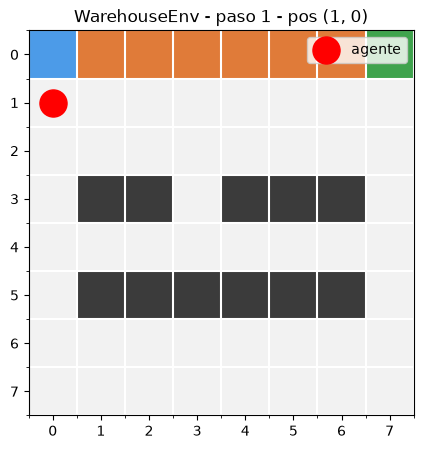

In [4]:
# render en modo matplotlib
env_mpl = WarehouseEnv(render_mode="matplotlib")
env_mpl.reset(seed=0)
env_mpl.step(1)   # baja a la ruta corta
env_mpl.render();

#### 3. Algoritmos implementados desde cero

Ambos comparten la política de comportamiento $\varepsilon$-greedy y el mismo registro por episodio
(recompensa total, pasos hasta la terminación y número de veces que el agente pasó por una zona de
congestión). La única diferencia está en el *target* de la actualización:

- SARSA (on-policy): $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma Q(s',a') - Q(s,a)]$ con $a'$ la
  acción que realmente se ejecutará.
- Q-Learning (off-policy): $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$.

En ambos casos, cuando $s'$ es terminal el target es simplemente $r$ (el valor de un estado terminal
es 0). El episodio truncado, en cambio, sí usa bootstrapping porque el estado no es terminal: solo se
corta la interacción.

In [5]:
def politica_epsilon_greedy(Q, estado, epsilon, rng):
    """Elige una accion epsilon-greedy. Los empates del argmax se rompen al azar."""
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    q = Q[estado]
    return int(rng.choice(np.flatnonzero(q == q.max())))


def _registro_vacio():
    return {"recompensa": [], "pasos": [], "congestiones": [], "exito": []}


def sarsa(env, n_episodios=8000, alpha=0.1, gamma=0.99, epsilon=0.2, seed=0):
    """SARSA tabular on-policy. Devuelve (Q, historial_por_episodio)."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    hist = _registro_vacio()

    for _ in range(n_episodios):
        estado, _ = env.reset()
        accion = politica_epsilon_greedy(Q, estado, epsilon, rng)
        total, pasos, congestiones = 0.0, 0, 0

        while True:
            sig_estado, r, terminated, truncated, info = env.step(accion)
            total += r
            pasos += 1
            congestiones += int(info["congestion"])

            if terminated:
                # El estado terminal no tiene valor futuro: el target es solo r.
                Q[estado, accion] += alpha * (r - Q[estado, accion])
                break

            sig_accion = politica_epsilon_greedy(Q, sig_estado, epsilon, rng)
            Q[estado, accion] += alpha * (r + gamma * Q[sig_estado, sig_accion] - Q[estado, accion])
            estado, accion = sig_estado, sig_accion

            if truncated:
                break

        hist["recompensa"].append(total)
        hist["pasos"].append(pasos)
        hist["congestiones"].append(congestiones)
        hist["exito"].append(bool(terminated))

    return Q, hist


def q_learning(env, n_episodios=8000, alpha=0.1, gamma=0.99, epsilon=0.2, seed=0):
    """Q-Learning tabular off-policy. Devuelve (Q, historial_por_episodio)."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    hist = _registro_vacio()

    for _ in range(n_episodios):
        estado, _ = env.reset()
        total, pasos, congestiones = 0.0, 0, 0

        while True:
            accion = politica_epsilon_greedy(Q, estado, epsilon, rng)
            sig_estado, r, terminated, truncated, info = env.step(accion)
            total += r
            pasos += 1
            congestiones += int(info["congestion"])

            objetivo = r if terminated else r + gamma * Q[sig_estado].max()
            Q[estado, accion] += alpha * (objetivo - Q[estado, accion])
            estado = sig_estado

            if terminated or truncated:
                break

        hist["recompensa"].append(total)
        hist["pasos"].append(pasos)
        hist["congestiones"].append(congestiones)
        hist["exito"].append(bool(terminated))

    return Q, hist

#### 4. Entrenamiento

In [6]:
ALPHA, GAMMA, EPSILON = 0.1, 0.99, 0.2
N_EPISODIOS, SEED = 20000, 42

env = WarehouseEnv()

Q_sarsa, hist_sarsa = sarsa(env, N_EPISODIOS, ALPHA, GAMMA, EPSILON, seed=SEED)
Q_qlearning, hist_qlearning = q_learning(env, N_EPISODIOS, ALPHA, GAMMA, EPSILON, seed=SEED)

# Registro por episodio requerido para el analisis de Task 4.
train = pd.concat([
    pd.DataFrame(hist_sarsa).assign(algoritmo="SARSA", episodio=lambda d: d.index),
    pd.DataFrame(hist_qlearning).assign(algoritmo="Q-Learning", episodio=lambda d: d.index),
], ignore_index=True)[["algoritmo", "episodio", "recompensa", "pasos", "congestiones", "exito"]]

print("Q-table SARSA     :", Q_sarsa.shape)
print("Q-table Q-Learning:", Q_qlearning.shape)
train.head()

Q-table SARSA     : (64, 4)
Q-table Q-Learning: (64, 4)


,algoritmo,episodio,recompensa,pasos,congestiones,exito
0,SARSA,0,-379.0,62,22,True
1,SARSA,1,-138.0,100,2,False
2,SARSA,2,-44.0,69,4,True
3,SARSA,3,-100.0,100,0,False
4,SARSA,4,-100.0,100,0,False


In [7]:
resumen_train = train.groupby("algoritmo").agg(
    recompensa_media=("recompensa", "mean"),
    recompensa_ultimos_2000=("recompensa", lambda s: s.iloc[-2000:].mean()),
    pasos_medios=("pasos", "mean"),
    congestiones_totales=("congestiones", "sum"),
    congestiones_por_episodio=("congestiones", "mean"),
    tasa_exito=("exito", "mean"),
).round(3)
resumen_train

,recompensa_media,recompensa_ultimos_2000,pasos_medios,congestiones_totales,congestiones_por_episodio,tasa_exito
algoritmo,,,,,,
Q-Learning,79.572,79.659,12.056,9801,0.490,0.999
SARSA,82.109,84.830,13.278,5828,0.291,0.999


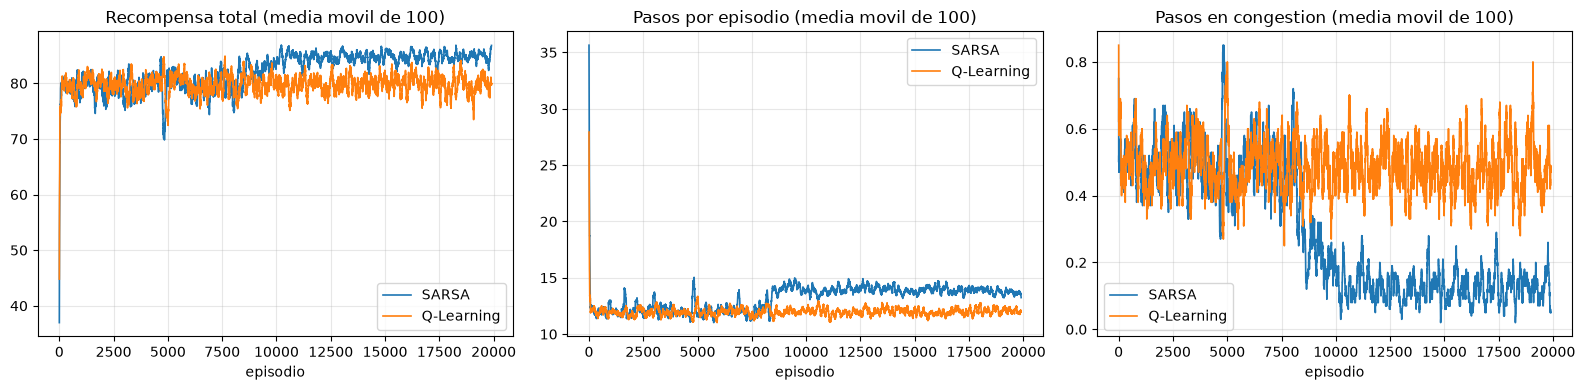

In [8]:
def media_movil(x, k=100):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(k) / k, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
series = [("recompensa", "Recompensa total"), ("pasos", "Pasos por episodio"),
          ("congestiones", "Pasos en congestion")]

for ax, (col, titulo) in zip(axes, series):
    for nombre, hist in [("SARSA", hist_sarsa), ("Q-Learning", hist_qlearning)]:
        ax.plot(media_movil(hist[col]), label=nombre, linewidth=1.2)
    ax.set_title(f"{titulo} (media movil de 100)")
    ax.set_xlabel("episodio")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

#### 5. Evaluación con política greedy pura (100 episodios, $\varepsilon = 0$)

In [9]:
def evaluar_greedy(env, Q, n_episodios=100, seed=123):
    """Ejecuta la politica greedy pura (epsilon = 0) y registra las mismas metricas."""
    rng = np.random.default_rng(seed)
    hist = _registro_vacio()

    for _ in range(n_episodios):
        estado, _ = env.reset()
        total, pasos, congestiones = 0.0, 0, 0
        while True:
            accion = politica_epsilon_greedy(Q, estado, 0.0, rng)
            estado, r, terminated, truncated, info = env.step(accion)
            total += r
            pasos += 1
            congestiones += int(info["congestion"])
            if terminated or truncated:
                break
        hist["recompensa"].append(total)
        hist["pasos"].append(pasos)
        hist["congestiones"].append(congestiones)
        hist["exito"].append(bool(terminated))

    return hist


eval_sarsa = evaluar_greedy(env, Q_sarsa, n_episodios=100)
eval_qlearning = evaluar_greedy(env, Q_qlearning, n_episodios=100)

evaluacion = pd.concat([
    pd.DataFrame(eval_sarsa).assign(algoritmo="SARSA", episodio=lambda d: d.index),
    pd.DataFrame(eval_qlearning).assign(algoritmo="Q-Learning", episodio=lambda d: d.index),
], ignore_index=True)[["algoritmo", "episodio", "recompensa", "pasos", "congestiones", "exito"]]

resumen_eval = evaluacion.groupby("algoritmo").agg(
    recompensa_media=("recompensa", "mean"),
    recompensa_std=("recompensa", "std"),
    pasos_medios=("pasos", "mean"),
    congestiones_por_episodio=("congestiones", "mean"),
    tasa_exito=("exito", "mean"),
).round(3)
resumen_eval

,recompensa_media,recompensa_std,pasos_medios,congestiones_por_episodio,tasa_exito
algoritmo,,,,,
Q-Learning,92.0,0.0,9.0,0.0,1.0
SARSA,90.0,0.0,11.0,0.0,1.0


El entorno es determinista y el estado inicial es siempre el mismo, así que los 100 episodios de
evaluación greedy son idénticos entre sí (desviación estándar 0). Se ejecutan igual porque la
consigna lo pide y porque sirven para confirmar que ninguna de las dos políticas se queda atascada ni
depende del azar del desempate: con $\varepsilon = 0$ y sin empates en el argmax, la trayectoria es
completamente reproducible.

#### 6. Políticas aprendidas

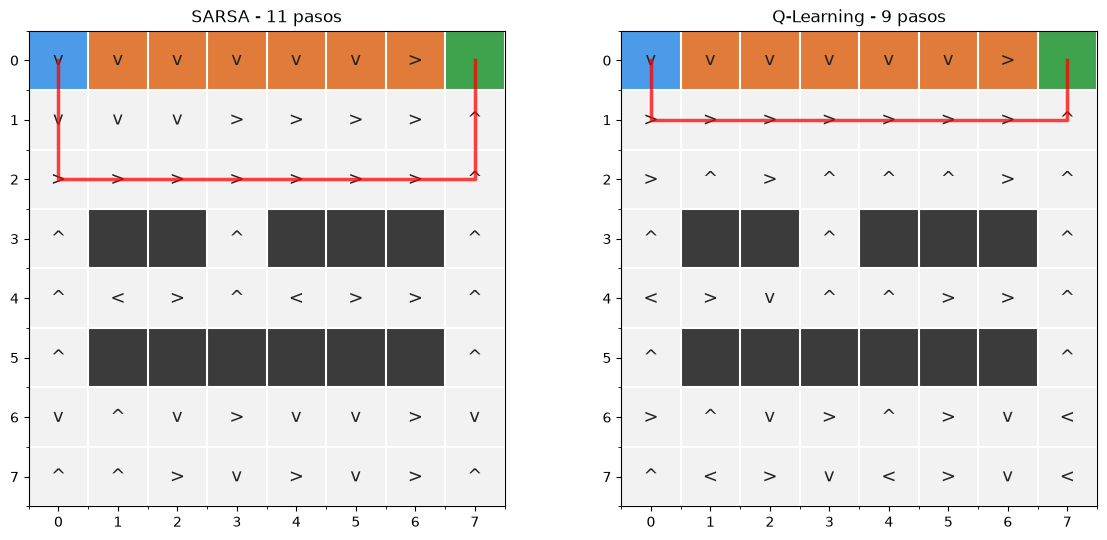

Ruta SARSA     : [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (1, 7), (0, 7)]
Ruta Q-Learning: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (0, 7)]


In [10]:
def ruta_greedy(env, Q):
    """Trayectoria que sigue la politica greedy desde el inicio."""
    estado, _ = env.reset()
    rng = np.random.default_rng(0)
    ruta = [env.pos]
    while True:
        accion = politica_epsilon_greedy(Q, estado, 0.0, rng)
        estado, _, terminated, truncated, _ = env.step(accion)
        ruta.append(env.pos)
        if terminated or truncated:
            return ruta


def dibujar_politica(env, Q, ruta, titulo, ax):
    cmap = ListedColormap(["#f2f2f2", "#4c9be8", "#3fa34d", "#3b3b3b", "#e07b39"])
    ax.imshow(env._grid_codificado(), cmap=cmap, vmin=0, vmax=4)

    for estado in range(env.observation_space.n):
        f, c = env.a_posicion(estado)
        if env.mapa[f][c] in "OG":
            continue
        ax.text(c, f, env.FLECHAS[int(Q[estado].argmax())], ha="center", va="center",
                fontsize=13, color="#222")

    fs, cs = zip(*ruta)
    ax.plot(cs, fs, color="red", linewidth=2.5, alpha=0.75, zorder=3)
    ax.set_xticks(np.arange(-0.5, env.n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.n_filas, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.set_xticks(range(env.n_cols)); ax.set_yticks(range(env.n_filas))
    ax.set_title(titulo)


ruta_s = ruta_greedy(env, Q_sarsa)
ruta_q = ruta_greedy(env, Q_qlearning)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
dibujar_politica(env, Q_sarsa, ruta_s, f"SARSA - {len(ruta_s) - 1} pasos", axes[0])
dibujar_politica(env, Q_qlearning, ruta_q, f"Q-Learning - {len(ruta_q) - 1} pasos", axes[1])
plt.tight_layout()
plt.show()

print("Ruta SARSA     :", ruta_s)
print("Ruta Q-Learning:", ruta_q)

#### 7. Registros exportados para Task 4

In [11]:
train.to_csv("metricas_entrenamiento.csv", index=False)
evaluacion.to_csv("metricas_evaluacion.csv", index=False)
np.save("q_sarsa.npy", Q_sarsa)
np.save("q_qlearning.npy", Q_qlearning)

print("metricas_entrenamiento.csv:", train.shape)
print("metricas_evaluacion.csv   :", evaluacion.shape)
print("q_sarsa.npy / q_qlearning.npy:", Q_sarsa.shape)

metricas_entrenamiento.csv: (40000, 6)
metricas_evaluacion.csv   : (200, 6)
q_sarsa.npy / q_qlearning.npy: (64, 4)


In [12]:
print(f"=== Entrenamiento ({N_EPISODIOS} episodios, epsilon = {EPSILON}) ===")
print(resumen_train.to_string())
print("\n=== Evaluacion greedy pura (100 episodios, epsilon = 0) ===")
print(resumen_eval.to_string())
print(f"\nCota teorica de la ruta optima con gamma={GAMMA}: "
      f"{-(1 - GAMMA**8) / (1 - GAMMA) + 100 * GAMMA**8:.2f} (sin descuento: 92.00)")

=== Entrenamiento (20000 episodios, epsilon = 0.2) ===
            recompensa_media  recompensa_ultimos_2000  pasos_medios  congestiones_totales  congestiones_por_episodio  tasa_exito
algoritmo                                                                                                                       
Q-Learning            79.572                   79.659        12.056                  9801                      0.490       0.999
SARSA                 82.109                   84.830        13.278                  5828                      0.291       0.999

=== Evaluacion greedy pura (100 episodios, epsilon = 0) ===
            recompensa_media  recompensa_std  pasos_medios  congestiones_por_episodio  tasa_exito
algoritmo                                                                                        
Q-Learning              92.0             0.0           9.0                        0.0         1.0
SARSA                   90.0             0.0          11.0                

#### 8. Hallazgos de Task 3

Con $\alpha=0.1$, $\gamma=0.99$, $\varepsilon=0.2$, 20000 episodios y semilla 42:

| Métrica | SARSA | Q-Learning |
|---|---|---|
| Recompensa media de entrenamiento | 82.11 | 79.57 |
| Recompensa media, últimos 2000 episodios | **84.83** | 79.66 |
| Pasos medios por episodio (entrenamiento) | 13.28 | 12.06 |
| Pasos en congestión por episodio (entrenamiento) | **0.291** | 0.490 |
| Recompensa en evaluación greedy (100 episodios) | 90.0 | **92.0** |
| Pasos en evaluación greedy | 11 | 9 |
| Pasos en congestión en evaluación greedy | 0 | 0 |

La predicción hecha en Task 2 se cumple en las dos direcciones:

- **En entrenamiento gana SARSA** (84.83 vs 79.66 en los últimos 2000 episodios). Al ser on-policy,
  incorpora en su target el riesgo de que la acción exploratoria lo tire a la banda de congestión, así
  que aprende a rodearla: pisa congestión 0.291 veces por episodio contra 0.490 de Q-Learning, un 41%
  menos.
- **En evaluación greedy gana Q-Learning** (92.0 vs 90.0). Sin exploración el entorno es determinista
  y no hay riesgo de resbalar, así que la ruta corta de 9 pasos que aprendió Q-Learning es
  efectivamente la óptima, y los 2 pasos extra del rodeo de SARSA se vuelven pérdida pura.
- Las políticas greedy son exactamente las dos rutas anticipadas: Q-Learning bordea la congestión por
  la fila 1 (9 pasos) y SARSA la rodea por la fila 2 (11 pasos).
- El valor de la ruta óptima en evaluación, 92.0, coincide exactamente con la cota teórica no
  descontada recalculada para este mapa ($8(-1)+100$), lo que confirma que Q-Learning convergió al
  óptimo real.
- Ambas políticas alcanzan la meta en el 100% de los episodios de evaluación, y durante el
  entrenamiento la tasa de éxito es de 99.9% (los truncamientos ocurren casi solo en los primeros
  episodios, cuando la política es prácticamente aleatoria).


### Task 4: análisis experimental y dictamen técnico

#### 1–2. Verificación de predicciones, convergencia y comportamiento diferencial


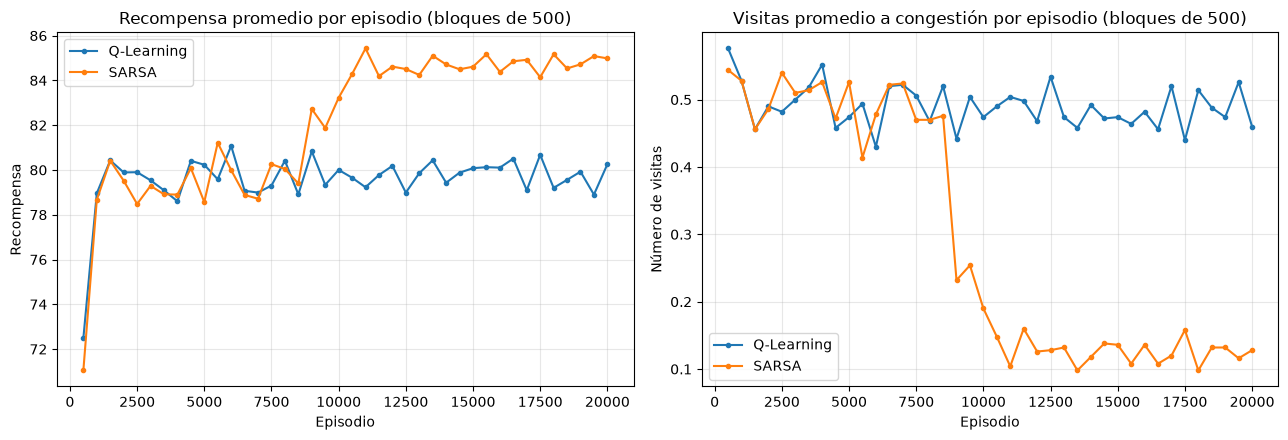

Inicio de separación sostenida: 9000


,algoritmo,bloque,episodio,recompensa,congestiones
17,Q-Learning,17,8999,80.832,0.442
18,Q-Learning,18,9499,79.334,0.504
19,Q-Learning,19,9999,80.002,0.474
20,Q-Learning,20,10499,79.654,0.490
21,Q-Learning,21,10999,79.228,0.504
57,SARSA,17,8999,82.724,0.232
58,SARSA,18,9499,81.876,0.254
59,SARSA,19,9999,83.224,0.190
60,SARSA,20,10499,84.284,0.148
61,SARSA,21,10999,85.428,0.104


In [13]:
# Promedios por bloques no solapados para reducir ruido sin ocultar la escala temporal.
TAM_BLOQUE = 500
bloques = (train.assign(bloque=lambda d: d['episodio'] // TAM_BLOQUE)
           .groupby(['algoritmo', 'bloque'], as_index=False)
           .agg(episodio=('episodio', 'max'), recompensa=('recompensa', 'mean'),
                congestiones=('congestiones', 'mean')))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for nombre, datos in bloques.groupby('algoritmo'):
    axes[0].plot(datos['episodio'], datos['recompensa'], marker='o', ms=3, label=nombre)
    axes[1].plot(datos['episodio'], datos['congestiones'], marker='o', ms=3, label=nombre)
for ax, titulo, ylabel in zip(axes, ['Recompensa promedio por episodio', 'Visitas promedio a congestión por episodio'], ['Recompensa', 'Número de visitas']):
    ax.set(title=f'{titulo} (bloques de {TAM_BLOQUE})', xlabel='Episodio', ylabel=ylabel)
    ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()
# Separación = 3 bloques seguidos con ventaja SARSA >=2 y >=0.10 visitas menos.
ancho = bloques.pivot(index='bloque', columns='algoritmo', values=['recompensa', 'congestiones'])
criterio = ((ancho['recompensa']['SARSA'] - ancho['recompensa']['Q-Learning'] >= 2) & (ancho['congestiones']['Q-Learning'] - ancho['congestiones']['SARSA'] >= .10))
sostenido = criterio.rolling(3).sum().eq(3)
primer_bloque = int(sostenido.idxmax() - 2) if sostenido.any() else None
episodio_separacion = primer_bloque * TAM_BLOQUE if primer_bloque is not None else None
print('Inicio de separación sostenida:', episodio_separacion)
display(bloques[bloques['bloque'].isin(range(max(0, (primer_bloque or 0)-1), (primer_bloque or 0)+4))].round(3))


**Contraste de las predicciones de Task 2.**

1. **Mayor recompensa durante entrenamiento para SARSA: confirmada.** En los últimos 2,000 episodios, SARSA obtuvo 84.83 frente a 79.66 de Q-Learning. Además, entró 0.291 veces por episodio en congestión frente a 0.490 (40.6% menos). Al ser *on-policy*, su target incorpora la siguiente acción realmente seleccionada por la política $\varepsilon$-greedy y el costo de una exploración accidental. Q-Learning actualiza hacia $\max_a Q(s',a)$ y aprende la ruta corta suponiendo conducta greedy futura, aunque durante el entrenamiento siga explorando.
2. **Mayor recompensa greedy para Q-Learning: confirmada.** Q-Learning consiguió 92 puntos y 9 pasos; SARSA, 90 puntos y 11 pasos. Ambas políticas tuvieron 100% de éxito y cero congestiones en 100 evaluaciones. Con $\varepsilon=0$ desaparece el riesgo exploratorio y los dos pasos adicionales son costo puro. Q-Learning igualó la cota no descontada $8(-1)+100=92$ (84.55 con descuento).
3. **Efecto de $\varepsilon$ e identidad con $\varepsilon=0$: parcialmente confirmada.** El caso $\varepsilon=0.2$ confirma la diferencia prevista. La identidad en $\varepsilon=0$ es asintótica bajo visitas suficientes; entrenar greedy desde cero no las garantiza. Cuando la conducta es greedy y se cumplen las condiciones de convergencia, SARSA usa la acción que maximiza Q y su target coincide con el de Q-Learning, por lo que ambos convergen a $Q^*$. La predicción matemática se sostiene, pero el protocolo principal no la prueba directamente.

La figura define visibilidad mediante un criterio reproducible: tres bloques consecutivos en los que SARSA aventaja por al menos 2 puntos y registra al menos 0.10 visitas menos. La primera separación sostenida comienza en el **episodio 9,000** y se mantiene en los bloques siguientes. El orden coincide con la teoría: tras descubrir rutas útiles, SARSA internaliza el riesgo exploratorio y se desplaza al pasillo seguro; Q-Learning conserva la ruta corta.


#### 3. Análisis de sensibilidad de $\alpha$ y $\varepsilon$

Se prueban tres combinaciones con cinco semillas, 20,000 episodios por corrida y $\gamma=0.99$. La tabla resume la media y desviación entre semillas de 100 evaluaciones greedy por tabla aprendida y cuántas semillas produjeron la ruta segura de 11 pasos.


In [14]:
COMBINACIONES = [(0.05, 0.10), (0.10, 0.20), (0.20, 0.30)]
SEMILLAS = [11, 22, 33, 44, 55]
resultados_sensibilidad = []
for alpha, epsilon in COMBINACIONES:
    for semilla in SEMILLAS:
        for nombre, entrenador in [('SARSA', sarsa), ('Q-Learning', q_learning)]:
            Q, hist = entrenador(WarehouseEnv(), N_EPISODIOS, alpha, GAMMA, epsilon, seed=semilla)
            ev = evaluar_greedy(WarehouseEnv(), Q, 100, seed=1000 + semilla)
            resultados_sensibilidad.append({'alpha':alpha, 'epsilon':epsilon, 'algoritmo':nombre, 'semilla':semilla, 'recompensa_eval':np.mean(ev['recompensa']), 'pasos_eval':np.mean(ev['pasos']), 'congestion_eval':np.mean(ev['congestiones']), 'recompensa_train_final':np.mean(hist['recompensa'][-2000:])})
sensibilidad = pd.DataFrame(resultados_sensibilidad)
tabla_sensibilidad = (sensibilidad.groupby(['alpha','epsilon','algoritmo']).agg(recompensa_greedy_media=('recompensa_eval','mean'), recompensa_greedy_std=('recompensa_eval','std'), recompensa_train_ultimos_2000=('recompensa_train_final','mean'), pasos_greedy=('pasos_eval','mean'), semillas_ruta_segura=('pasos_eval',lambda x:int((x >= 11).sum()))).round(3))
tabla_sensibilidad


recompensa_greedy_media  recompensa_greedy_std  \
alpha epsilon algoritmo                                                    
0.05  0.1     Q-Learning                     92.0                  0.000   
              SARSA                          92.0                  0.000   
0.10  0.2     Q-Learning                     92.0                  0.000   
              SARSA                          90.0                  0.000   
0.20  0.3     Q-Learning                     92.0                  0.000   
              SARSA                          52.0                 84.971   

                          recompensa_train_ultimos_2000  pasos_greedy  \
alpha epsilon algoritmo                                                 
0.05  0.1     Q-Learning                         86.768           9.0   
              SARSA                              86.883           9.0   
0.10  0.2     Q-Learning                         79.549           9.0   
              SARSA                              84.832          11.0   
0.20  0.3     Q-Learning                         70.840           9.0   
              SARSA                              79.798          28.8   

                          semillas_ruta_segura  
alpha epsilon algoritmo                         
0.05  0.1     Q-Learning                     0  
              SARSA                          0  
0.10  0.2     Q-Learning                     0  
              SARSA                          5  
0.20  0.3     Q-Learning                     0  
              SARSA                          5

Recomendamos **$(\alpha,\varepsilon)=(0.10,0.20)$ para SARSA**: produjo la ruta segura de 11 pasos en las cinco semillas, alcanzó 90.0 puntos greedy sin variación y obtuvo 84.832 puntos de entrenamiento tardío. Con $(0.05,0.10)$ ambos algoritmos aprendieron la misma ruta corta de 92 puntos: la exploración no fue suficiente para que SARSA valorara el riesgo diferencial. Con $(0.20,0.30)$ SARSA eligió rutas de al menos 11 pasos en las cinco semillas, pero fue inestable (52.0 puntos greedy, desviación 84.971 y 28.8 pasos medios), mientras el costo exploratorio redujo su recompensa tardía a 79.798. Q-Learning obtuvo 92 puntos y 9 pasos en todas las combinaciones, aunque su recompensa de entrenamiento cayó de 86.768 a 70.840 al aumentar $\varepsilon$. En producción no se mantendría exploración aleatoria: se entrenaría y validaría fuera de línea y se desplegaría una política greedy con capa de seguridad.

#### 4. Investigación bibliográfica

Ajabshir, Güzel y Bostanci (2022) estudian navegación descentralizada de múltiples robots en espacios continuos parcialmente obstruidos: cada agente debe alcanzar su objetivo evitando obstáculos y colisiones sin controlador central. Aplican Q-Learning *model-free*, pero atacan una limitación presente en este laboratorio: el crecimiento combinatorio de la tabla al agregar variables. Separan características no superpuestas y comprimen la representación (CCSS); después añaden priorización de objetos y reducción de datos sensoriales en un controlador generalizado (GCC). Discretizan observaciones continuas, moldean la recompensa para favorecer acercarse a la meta y reducen gradualmente la exploración.

Reportan cerca de **70% menos memoria**, navegación con al menos 18 robots y soluciones cercanas al óptimo. Para tres robots, CCSS y el controlador no comprimido muestran curvas similares y una solución razonable después de unos 400,000 episodios: la ventaja central es memoria y escalabilidad, no una nueva regla TD. El método mitiga la explosión del espacio y admite observaciones continuas mediante discretización y selección de características. No elimina, sin embargo, la alta demanda de interacciones, la dependencia de discretización, recompensa e hiperparámetros, la falta de seguridad durante exploración ni la limitada generalización. El traslado a Deep Q-Learning queda como trabajo futuro y tampoco sustituye validación física con ruido sensorial y dinámica real.

#### 5. Dictamen técnico para gerencia

Recomendamos **SARSA para aprender una política destinada al robot real** si existe exploración en línea o si entrar en congestión implica riesgo humano, daño o interrupción. La evidencia: en los últimos 2,000 episodios obtuvo 84.83 puntos frente a 79.66 de Q-Learning y redujo las visitas a congestión de 0.490 a 0.291, a cambio de una ruta greedy de 11 pasos y 90 puntos. Q-Learning se recomienda solo si todo el aprendizaje ocurre en un simulador representativo, la política se congela antes del despliegue y prima el rendimiento: alcanzó la cota óptima de 92 puntos en 9 pasos, sin congestión en evaluación greedy. Antes de producción se requieren tráfico dinámico y ruido en un gemelo digital, múltiples inicios y entregas, más semillas, transferencia simulación-real, sensores redundantes, parada de emergencia, restricciones explícitas y un piloto supervisado.

#### Referencias (APA 7.ª edición)

Ajabshir, V. B., Güzel, M. S., & Bostanci, E. (2022). A low-cost Q-learning-based approach to handle continuous space problems for decentralized multi-agent robot navigation in cluttered environments. *IEEE Access, 10*, 35287–35301. https://doi.org/10.1109/ACCESS.2022.3163393

Farama Foundation. (2025). *Gymnasium documentation*. https://gymnasium.farama.org/

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). The MIT Press. http://incompleteideas.net/book/the-book-2nd.html
